In [ ]:
# --- Cell 0: Stable env for Module-6 (Backtesting) ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Pin core libs to match the model you trained in Module-4
# (These play nicely with Colab's Python 3.12 + TF 2.19 constraints)
%pip -q install --upgrade --force-reinstall --no-cache-dir \
  "numpy==2.1.3" "pandas==2.2.2" "scipy==1.14.1" "scikit-learn==1.5.2" "joblib==1.4.2"

# Install helpers WITHOUT pulling new numpy/pandas (prevent conflicts)
%pip -q install --no-deps yfinance pandas-ta pyyaml

import os
print("Restarting runtime to load pinned libraries...")
os.kill(os.getpid(), 9)


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 181.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 156.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 175.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 171.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 183.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 221.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 239.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.8/347.8 kB 95.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confl

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/MyDrive/ARVisionGold"

# Minimal installs (avoid numpy/pandas re-pins)
%pip -q install pyyaml joblib yfinance pandas-ta

import os, yaml, json, pandas as pd, numpy as np
import joblib

# paths & configs
with open(f"{ROOT}/configs/paths.yaml") as f:
    P = yaml.safe_load(f)
with open(f"{ROOT}/configs/signals.yaml") as f:
    SIG = yaml.safe_load(f)
with open(f"{ROOT}/configs/model.yaml") as f:
    MCFG = yaml.safe_load(f)

CSV_PATH    = P["data"]["processed_csv"]
MODEL_PATH  = P["artifacts"]["model_rf"]
BT_DIR      = P["artifacts"]["backtest_dir"]
os.makedirs(BT_DIR, exist_ok=True)

print("CSV:", CSV_PATH)
print("MODEL:", MODEL_PATH)


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 19.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pand

In [1]:
# --- Cell 1: Imports + versions ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT = "/content/drive/MyDrive/ARVisionGold"

import numpy as np, pandas as pd, scipy, sklearn, joblib, yaml, json, os
print("numpy:", np.__version__, "| pandas:", pd.__version__,
      "| scipy:", scipy.__version__, "| sklearn:", sklearn.__version__)

with open(f"{ROOT}/configs/paths.yaml") as f:
    P = yaml.safe_load(f)
with open(f"{ROOT}/configs/model.yaml") as f:
    MCFG = yaml.safe_load(f)

CSV_PATH    = P["data"]["processed_csv"]
MODEL_PATH  = P["artifacts"]["model_rf"]
BT_DIR      = P["artifacts"]["backtest_dir"]
os.makedirs(BT_DIR, exist_ok=True)

print("CSV:", CSV_PATH)
print("MODEL:", MODEL_PATH)


Mounted at /content/drive
numpy: 2.1.3 | pandas: 2.2.2 | scipy: 1.14.1 | sklearn: 1.5.2
CSV: /content/drive/MyDrive/ARVisionGold/data/processed/gold_data.csv
MODEL: /content/drive/MyDrive/ARVisionGold/artifacts/models/gold_price_predictor.joblib


In [2]:
df = pd.read_csv(CSV_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
rf = joblib.load(MODEL_PATH)

feature_cols = list(getattr(rf, "feature_names_in_", MCFG["features"]["include"]))
base_cols = ["Date","Open","High","Low","Close","ATR"]  # needed for fills & SL/TP
for c in base_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column in CSV: {c}")

# Make a clean features frame without targets/leakage
Xall = df[feature_cols].copy()
Yall = df["NextCloseUp"].astype(int)

print("Rows:", len(df), "| Feature cols:", len(feature_cols))
Xall.tail(2)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Rows: 2446 | Feature cols: 13


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,Open,High,Low,Close,Volume,RSI,MACD,MACD_signal,MACD_hist,BB_upper,BB_middle,BB_lower,ATR
2444,3775.300049,3775.300049,3775.300049,3775.300049,19308,72.655998,83.267500,3.439891,79.827609,3810.312531,3657.014990,3503.717450,40.289579
2445,3754.800049,3827.600098,3754.800049,3820.899902,8860,75.723452,86.744426,5.533454,81.210973,3818.635072,3674.374988,3530.114904,42.611755


In [3]:
def fuse_signal(model_label:str, model_prob:float, cfg:dict, candle_proxy:str=None):
    # Optional: candle_proxy = "BULLISH"/"BEARISH" using Close vs Open of current bar
    bull_words = set(map(str.upper, cfg["fusion"]["bullish_words"]))
    bear_words = set(map(str.upper, cfg["fusion"]["bearish_words"]))
    th = cfg["thresholds"]

    up = (model_label or "").upper() in bull_words
    dn = (model_label or "").upper() in bear_words
    ct_bull = (candle_proxy or "").upper() == "BULLISH"
    ct_bear = (candle_proxy or "").upper() == "BEARISH"

    # If you want CV influence during backtest, set require_agreement=True in signals.yaml
    require_agree = cfg["fusion"].get("require_agreement", False)
    if require_agree:
        if up and model_prob >= th["rf_prob_buy"] and ct_bull:  return "STRONG BUY"
        if dn and model_prob >= th["rf_prob_sell"] and ct_bear: return "STRONG SELL"
    else:
        if up and model_prob >= th["rf_prob_buy"]:  return "STRONG BUY"
        if dn and model_prob >= th["rf_prob_sell"]: return "STRONG SELL"

    if model_prob < th["no_trade_band"]: return "WAIT"
    if up: return "BUY"
    if dn: return "SELL"
    return "WAIT"


In [4]:
def simulate_trade(row_t, row_next, side:str, atr_mult_sl:float, atr_mult_tp:float):
    """
    row_t     = current bar (features/ATR etc.)
    row_next  = next bar (entry/exit)
    side      = 'LONG' or 'SHORT'
    entry     = next bar Open (no lookahead)
    Exit rule: if SL/TP touched intrabar => exit at SL/TP; otherwise exit at Close (next bar).
    Returns dict with pnl, pnl_pct, exit_reason, entry, exit.
    """
    entry = float(row_next["Open"])
    atr   = float(row_t["ATR"])
    sl_gap = atr_mult_sl * atr
    tp_gap = atr_mult_tp * atr

    hi = float(row_next["High"])
    lo = float(row_next["Low"])
    close = float(row_next["Close"])

    if side == "LONG":
        sl = entry - sl_gap
        tp = entry + tp_gap
        # hit order: SL first if low < sl; TP first if high > tp; else close
        if lo <= sl:   exit_price, reason = sl, "SL"
        elif hi >= tp: exit_price, reason = tp, "TP"
        else:          exit_price, reason = close, "CLOSE"
        pnl = exit_price - entry

    else:  # SHORT
        sl = entry + sl_gap
        tp = entry - tp_gap
        if hi >= sl:   exit_price, reason = sl, "SL"
        elif lo <= tp: exit_price, reason = tp, "TP"
        else:          exit_price, reason = close, "CLOSE"
        pnl = entry - exit_price

    pnl_pct = pnl / entry if entry != 0 else 0.0
    return {
        "entry": entry, "exit": exit_price, "pnl": pnl, "pnl_pct": pnl_pct,
        "sl": sl, "tp": tp, "exit_reason": reason
    }


In [5]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def run_backtest(df: pd.DataFrame, X: pd.DataFrame, rf, sig_cfg:dict,
                 start_idx:int=250, atr_sl:float=1.5, atr_tp:float=2.0,
                 use_candle_proxy:bool=False):
    """
    For each t from start_idx to len-2:
      - Predict using features at t
      - Build signal via rules
      - If BUY/SELL -> open next bar at open[t+1], manage with ATR stops
    """
    trades = []
    preds  = []
    probs  = []
    y_true = []

    # ensure alignment
    assert len(df) == len(X), "df/X length mismatch"

    for t in range(start_idx, len(df)-1):
        row = df.loc[t]
        row_next = df.loc[t+1]

        x = X.loc[[t]]
        proba = 0.5
        try:
            proba = float(rf.predict_proba(x)[0].max())
            label_idx = int(rf.predict(x)[0])
        except Exception:
            label_idx = int(rf.predict(x)[0])

        label = "UP" if label_idx == 1 else "DOWN"
        candle_proxy = None
        if use_candle_proxy:
            candle_proxy = "BULLISH" if (row["Close"] >= row["Open"]) else "BEARISH"

        signal = fuse_signal(label, proba, sig_cfg, candle_proxy=candle_proxy)

        # collect classification stats vs actual NextCloseUp (optional)
        preds.append(1 if label == "UP" else 0)
        y_true.append(int(row["NextCloseUp"]))
        probs.append(proba)

        if signal in ("STRONG BUY","BUY"):
            tr = simulate_trade(row, row_next, side="LONG", atr_mult_sl=atr_sl, atr_mult_tp=atr_tp)
            tr.update({"t_entry": row["Date"], "t_exit": row_next["Date"], "side":"LONG",
                       "model_label":label, "prob":proba, "signal":signal})
            trades.append(tr)

        elif signal in ("STRONG SELL","SELL"):
            tr = simulate_trade(row, row_next, side="SHORT", atr_mult_sl=atr_sl, atr_mult_tp=atr_tp)
            tr.update({"t_entry": row["Date"], "t_exit": row_next["Date"], "side":"SHORT",
                       "model_label":label, "prob":proba, "signal":signal})
            trades.append(tr)

    # Equity curve & metrics
    trades_df = pd.DataFrame(trades)
    if not trades_df.empty:
        trades_df["equity"] = (1.0 + trades_df["pnl_pct"]).cumprod()
        cum = trades_df["equity"]
        dd = (cum / cum.cummax()) - 1.0
        max_dd = float(dd.min())
        wins = trades_df.loc[trades_df["pnl"] > 0, "pnl"].sum()
        losses = -trades_df.loc[trades_df["pnl"] <= 0, "pnl"].sum()
        profit_factor = float(wins / losses) if losses > 0 else float("inf")
    else:
        max_dd = 0.0; profit_factor = 0.0

    # classification metrics
    acc = accuracy_score(y_true, preds) if y_true else 0.0
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0, pos_label=1)

    summary = {
        "n_bars": int(len(df)),
        "n_trades": int(len(trades)),
        "accuracy_updown": float(acc),
        "precision_up": float(prec),
        "recall_up": float(rec),
        "f1_up": float(f1),
        "profit_factor": float(profit_factor),
        "max_drawdown": float(max_dd),
        "final_equity": float(trades_df["equity"].iloc[-1]) if not trades_df.empty else 1.0,
        "atr_sl": atr_sl, "atr_tp": atr_tp,
        "start_idx": start_idx,
        "use_candle_proxy": use_candle_proxy,
    }
    return trades_df, summary


In [9]:
# Ensure configs/vars are loaded (needed after any runtime restart)
import yaml, os

ROOT = "/content/drive/MyDrive/ARVisionGold"

# Load signals.yaml -> SIG
with open(f"{ROOT}/configs/signals.yaml") as f:
    SIG = yaml.safe_load(f)

# If X not prepared yet, build it from df using the training feature list
if 'X' not in globals():
    X = df[feature_cols].copy()

# Pull ATR SL/TP from SIG with safe fallbacks
atr_sl = SIG.get("risk", {}).get("atr_multiple_sl", 1.5)
atr_tp = SIG.get("risk", {}).get("atr_multiple_tp", 2.0)

print("SIG loaded ✔  |  X shape:", X.shape,  "|  atr_sl:", atr_sl,  "|  atr_tp:", atr_tp)


SIG loaded ✔  |  X shape: (2446, 13) |  atr_sl: 1.5 |  atr_tp: 2.0


In [10]:
# Align features to model training order
X = df[feature_cols].copy()

trades_df, summary = run_backtest(
    df=df, X=X, rf=rf, sig_cfg=SIG,
    start_idx=250,       # skip early warmup bars
    atr_sl=SIG["risk"]["atr_multiple_sl"],
    atr_tp=SIG["risk"]["atr_multiple_tp"],
    use_candle_proxy=False  # True => use bullish/bearish of current bar as CV proxy
)

# Save artifacts
trades_path = f"{BT_DIR}/trades.csv"
equity_path = f"{BT_DIR}/equity_curve.csv"
summary_path = f"{BT_DIR}/summary.json"

if not trades_df.empty:
    trades_df.to_csv(trades_path, index=False)
    trades_df[["t_exit","equity"]].to_csv(equity_path, index=False)
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved:")
print(" -", trades_path)
print(" -", equity_path)
print(" -", summary_path)
summary


Saved:
 - /content/drive/MyDrive/ARVisionGold/artifacts/backtests/trades.csv
 - /content/drive/MyDrive/ARVisionGold/artifacts/backtests/equity_curve.csv
 - /content/drive/MyDrive/ARVisionGold/artifacts/backtests/summary.json


{'n_bars': 2446,
 'n_trades': 2195,
 'accuracy_updown': 0.8724373576309795,
 'precision_up': 0.9989035087719298,
 'recall_up': 0.7655462184873949,
 'f1_up': 0.8667935299714558,
 'profit_factor': 2.7955127586236608,
 'max_drawdown': -0.3810872377465079,
 'final_equity': 960.8637931659513,
 'atr_sl': 1.5,
 'atr_tp': 2.0,
 'start_idx': 250,
 'use_candle_proxy': False}

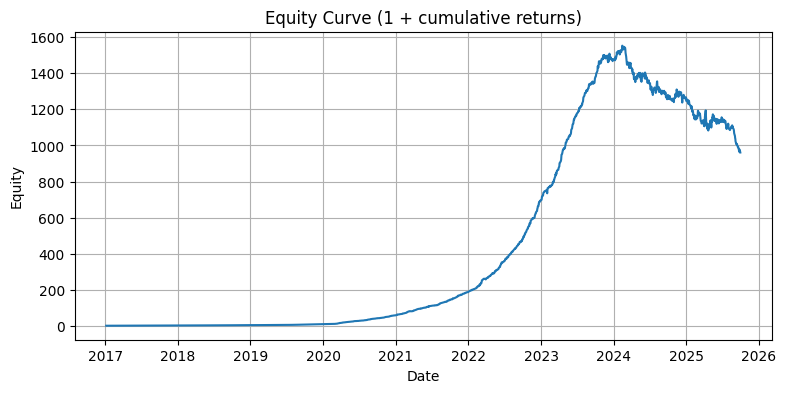

In [11]:
import matplotlib.pyplot as plt

if not trades_df.empty:
    plt.figure(figsize=(9,4))
    plt.plot(pd.to_datetime(trades_df["t_exit"]), trades_df["equity"])
    plt.title("Equity Curve (1 + cumulative returns)")
    plt.xlabel("Date"); plt.ylabel("Equity")
    plt.grid(True)
    plt.show()
else:
    print("No trades generated with current thresholds. Try lowering rf_prob_* or disable require_agreement.")


In [12]:
def sweep_thresholds(rf_prob_vals=(0.55,0.60,0.65)):
    best = None
    for v in rf_prob_vals:
        SIG2 = json.loads(json.dumps(SIG))
        SIG2["thresholds"]["rf_prob_buy"]  = float(v)
        SIG2["thresholds"]["rf_prob_sell"] = float(v)
        _, summ = run_backtest(df, X, rf, SIG2, start_idx=250,
                               atr_sl=SIG2["risk"]["atr_multiple_sl"],
                               atr_tp=SIG2["risk"]["atr_multiple_tp"])
        row = {"rf_prob":v, **summ}
        if (best is None) or (row["final_equity"] > best["final_equity"]):
            best = row
        print(row)
    print("\nBest by final_equity:", best)
    return best

best = sweep_thresholds((0.55,0.60,0.62,0.65,0.68))


{'rf_prob': 0.55, 'n_bars': 2446, 'n_trades': 2195, 'accuracy_updown': 0.8724373576309795, 'precision_up': 0.9989035087719298, 'recall_up': 0.7655462184873949, 'f1_up': 0.8667935299714558, 'profit_factor': 2.7955127586236608, 'max_drawdown': -0.3810872377465079, 'final_equity': 960.8637931659513, 'atr_sl': 1.5, 'atr_tp': 2.0, 'start_idx': 250, 'use_candle_proxy': False}
{'rf_prob': 0.6, 'n_bars': 2446, 'n_trades': 2195, 'accuracy_updown': 0.8724373576309795, 'precision_up': 0.9989035087719298, 'recall_up': 0.7655462184873949, 'f1_up': 0.8667935299714558, 'profit_factor': 2.7955127586236608, 'max_drawdown': -0.3810872377465079, 'final_equity': 960.8637931659513, 'atr_sl': 1.5, 'atr_tp': 2.0, 'start_idx': 250, 'use_candle_proxy': False}
{'rf_prob': 0.62, 'n_bars': 2446, 'n_trades': 2195, 'accuracy_updown': 0.8724373576309795, 'precision_up': 0.9989035087719298, 'recall_up': 0.7655462184873949, 'f1_up': 0.8667935299714558, 'profit_factor': 2.7955127586236608, 'max_drawdown': -0.3810872377